In [1]:
# ============================================================
# 1) Import libraries and check environment
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from scipy import io
import os

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# 2) Set random seeds
# ============================================================

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

In [3]:
# ============================================================
# 3) Configuration
# ============================================================

CONFIG = {
    'batch_size': 32,
    'noise_dim': 100,
    'num_epochs': 15,
    'learning_rate_gen': 0.0002,
    'learning_rate_disc': 0.0002,
    'beta_1': 0.5,
    'sample_interval': 5,
    'disc_steps': 4
}

TARGET = 32
CONFIG['image_height'] = TARGET
CONFIG['image_width'] = TARGET

In [4]:
# ============================================================
# 4) Load HODA dataset
# ============================================================

def get_dataset(data_path='/content/Data_hoda_full.mat'):
    dataset = io.loadmat(data_path)
    x_data = np.squeeze(dataset['Data'])

    total_samples = x_data.shape[0]
    print(f"Total samples in dataset: {total_samples}")

    max_r = 0
    max_c = 0

    for img in x_data:
        r, c = img.shape

        if r > max_r:
            max_r = r

        if c > max_c:
            max_c = c

    print(f"Max image height: {max_r}")
    print(f"Max image width: {max_c}")

    max_dim = max(max_r, max_c)
    H, W = max_dim, max_dim

    return x_data, H, W, total_samples

In [5]:
# ============================================================
# 5) Image preprocessing generator
# ============================================================

def image_generator(x_data, H, W):
    for img in x_data:
        r, c = img.shape

        canvas = np.zeros((H, W), dtype=np.float32)

        r_start = (H - r) // 2
        c_start = (W - c) // 2
        canvas[r_start:r_start + r, c_start:c_start + c] = img.astype(np.float32)

        canvas = canvas / 255.0

        canvas = tf.image.resize(
            canvas[..., np.newaxis],
            [TARGET, TARGET],
            method='area'
        ).numpy()

        canvas = np.clip(canvas, 0.0, 1.0)

        canvas = (canvas * 2.0) - 1.0

        yield canvas.astype(np.float32)

In [6]:
# ============================================================
# 6) Build TensorFlow dataset
# ============================================================

x_data, H, W, total_samples = get_dataset()

train_dataset = tf.data.Dataset.from_generator(
    lambda: image_generator(x_data, H, W),
    output_signature=tf.TensorSpec(shape=(TARGET, TARGET, 1), dtype=tf.float32)
)

train_dataset = (
    train_dataset
    .shuffle(
        buffer_size=5000,
        seed=RANDOM_SEED,
        reshuffle_each_iteration=True
    )
    .batch(CONFIG['batch_size'], drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

Total samples in dataset: 60000
Max image height: 62
Max image width: 51


In [7]:
# ============================================================
# 7) Generator model
# ============================================================

def build_generator(noise_dim, img_h, img_w):
    init_h = img_h // 4
    init_w = img_w // 4

    model = models.Sequential(name='Generator')

    model.add(layers.Input(shape=(noise_dim,)))

    model.add(layers.Dense(init_h * init_w * 256, use_bias=False))
    model.add(layers.Reshape((init_h, init_w, 256)))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(128, 5, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.ReLU())

    model.add(layers.Conv2D(1, 5, padding='same', activation='tanh'))

    return model

In [8]:
# ============================================================
# 8) Discriminator model
# ============================================================

def build_discriminator(img_h, img_w):
    model = models.Sequential(name='Discriminator')

    model.add(layers.Input(shape=(img_h, img_w, 1)))

    model.add(layers.Conv2D(64, 5, strides=2, padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.5))

    model.add(layers.Conv2D(128, 5, strides=2, padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.5))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

In [9]:
# ============================================================
# 9) Create models and optimizers
# ============================================================

generator = build_generator(
    CONFIG['noise_dim'],
    CONFIG['image_height'],
    CONFIG['image_width']
)

discriminator = build_discriminator(
    CONFIG['image_height'],
    CONFIG['image_width']
)

generator.summary()
discriminator.summary()

bce_loss = tf.keras.losses.BinaryCrossentropy()

gen_optimizer = tf.keras.optimizers.Adam(
    learning_rate=CONFIG['learning_rate_gen'],
    beta_1=CONFIG['beta_1']
)

disc_optimizer = tf.keras.optimizers.Adam(
    learning_rate=CONFIG['learning_rate_disc'],
    beta_1=CONFIG['beta_1']
)

fixed_noise = tf.random.normal(
    [16, CONFIG['noise_dim']],
    dtype=tf.float32
)

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16384)          │     1,638,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 1)      │         1,601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,665,793 (10.17 MB)

 Trainable params: 2,664,897 (10.17 MB)

 Non-trainable params: 896 (3.50 KB)

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,785 (839.00 KB)

 Trainable params: 214,785 (839.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ============================================================
# 10) Display generated samples
# ============================================================

def generate_and_display(gen, epoch, noise, n=16):
    imgs = gen(noise, training=False)

    imgs = (imgs + 1.0) / 2.0

    fig = plt.figure(figsize=(4, 4))

    for i in range(n):
        plt.subplot(4, 4, i + 1)
        plt.imshow(
            imgs[i, :, :, 0],
            cmap='gray',
            interpolation='nearest',
            vmin=0,
            vmax=1
        )
        plt.axis('off')

    plt.suptitle(f'Epoch {epoch}')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [11]:
# ============================================================
# 11) One training step
# ============================================================

@tf.function
def train_step(real_imgs):
    batch_size = tf.shape(real_imgs)[0]

    d_loss_total = tf.constant(0.0, dtype=tf.float32)

    for _ in range(CONFIG['disc_steps']):
        noise = tf.random.normal(
            [batch_size, CONFIG['noise_dim']],
            dtype=tf.float32
        )

        fake_imgs = generator(noise, training=False)

        real_labels = tf.ones((batch_size, 1), dtype=tf.float32) * 0.9
        fake_labels = tf.zeros((batch_size, 1), dtype=tf.float32)

        combined_imgs = tf.concat([fake_imgs, real_imgs], axis=0)
        labels = tf.concat([fake_labels, real_labels], axis=0)

        indices = tf.random.shuffle(tf.range(tf.shape(combined_imgs)[0]))
        combined_imgs = tf.gather(combined_imgs, indices)
        labels = tf.gather(labels, indices)

        with tf.GradientTape() as disc_tape:
            predictions = discriminator(combined_imgs, training=True)
            d_loss = bce_loss(labels, predictions)

        d_grads = disc_tape.gradient(
            d_loss,
            discriminator.trainable_variables
        )

        disc_optimizer.apply_gradients(
            zip(d_grads, discriminator.trainable_variables)
        )

        d_loss_total += d_loss

    d_loss_avg = d_loss_total / tf.cast(CONFIG['disc_steps'], tf.float32)

    noise = tf.random.normal(
        [batch_size, CONFIG['noise_dim']],
        dtype=tf.float32
    )

    target_labels = tf.ones((batch_size, 1), dtype=tf.float32)

    with tf.GradientTape() as gen_tape:
        generated_imgs = generator(noise, training=True)
        predictions = discriminator(generated_imgs, training=False)
        g_loss = bce_loss(target_labels, predictions)

    g_grads = gen_tape.gradient(
        g_loss,
        generator.trainable_variables
    )

    gen_optimizer.apply_gradients(
        zip(g_grads, generator.trainable_variables)
    )

    return d_loss_avg, g_loss

In [12]:
# ============================================================
# 12) Full training loop
# ============================================================

def train_gan(dataset, config):
    history = {
        'd_loss': [],
        'g_loss': []
    }

    for epoch in range(config['num_epochs']):
        print(f"\nEpoch {epoch + 1}/{config['num_epochs']}")

        epoch_d_loss = []
        epoch_g_loss = []
        batch_num = 0

        for real_imgs in dataset:
            batch_num += 1

            d_loss, g_loss = train_step(real_imgs)

            epoch_d_loss.append(float(d_loss.numpy()))
            epoch_g_loss.append(float(g_loss.numpy()))

            if batch_num % 50 == 0:
                print(
                    f"  Batch {batch_num}: "
                    f"D={np.mean(epoch_d_loss[-50:]):.4f}, "
                    f"G={np.mean(epoch_g_loss[-50:]):.4f}"
                )

        mean_d_loss = np.mean(epoch_d_loss)
        mean_g_loss = np.mean(epoch_g_loss)

        history['d_loss'].append(mean_d_loss)
        history['g_loss'].append(mean_g_loss)

        print(
            f"Epoch {epoch + 1} finished: "
            f"D={mean_d_loss:.4f}, "
            f"G={mean_g_loss:.4f}"
        )

        if (epoch + 1) % config['sample_interval'] == 0:
            generate_and_display(
                generator,
                epoch + 1,
                fixed_noise
            )

    return history


Epoch 1/15
  Batch 50: D=0.2384, G=5.0837
  Batch 100: D=0.3049, G=2.7006
  Batch 150: D=0.5035, G=1.4778
  Batch 200: D=0.4283, G=1.7497
  Batch 250: D=0.4712, G=1.5219
  Batch 300: D=0.5552, G=1.3084
  Batch 350: D=0.5956, G=1.0698
  Batch 400: D=0.5999, G=1.0312
  Batch 450: D=0.5678, G=1.0751
  Batch 500: D=0.5732, G=1.0407
  Batch 550: D=0.5937, G=1.0207
  Batch 600: D=0.5982, G=1.0137
  Batch 650: D=0.6026, G=0.9745
  Batch 700: D=0.5953, G=1.0165
  Batch 750: D=0.6018, G=0.9889
  Batch 800: D=0.6029, G=0.9855
  Batch 850: D=0.6054, G=0.9798
  Batch 900: D=0.6090, G=0.9527
  Batch 950: D=0.6119, G=0.9609
  Batch 1000: D=0.6101, G=0.9761
  Batch 1050: D=0.6126, G=0.9891
  Batch 1100: D=0.6154, G=0.9493
  Batch 1150: D=0.6224, G=0.9472
  Batch 1200: D=0.6153, G=0.9211
  Batch 1250: D=0.6170, G=0.9782
  Batch 1300: D=0.6182, G=0.9584
  Batch 1350: D=0.6158, G=0.9009
  Batch 1400: D=0.6224, G=0.9176
  Batch 1450: D=0.6162, G=0.9449
  Batch 1500: D=0.6185, G=0.9622
  Batch 1550: D=0.

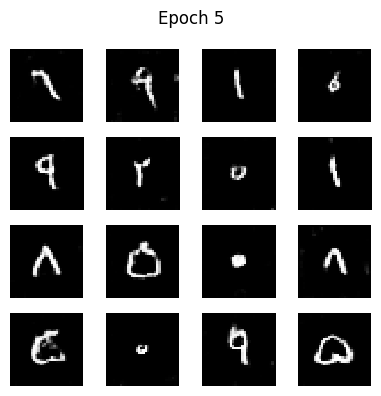


Epoch 6/15
  Batch 50: D=0.6704, G=0.8656
  Batch 100: D=0.6646, G=0.8534
  Batch 150: D=0.6699, G=0.8583
  Batch 200: D=0.6652, G=0.8690
  Batch 250: D=0.6657, G=0.8619
  Batch 300: D=0.6656, G=0.8820
  Batch 350: D=0.6694, G=0.8702
  Batch 400: D=0.6721, G=0.8639
  Batch 450: D=0.6704, G=0.8523
  Batch 500: D=0.6699, G=0.8481
  Batch 550: D=0.6700, G=0.8559
  Batch 600: D=0.6691, G=0.8639
  Batch 650: D=0.6692, G=0.8627
  Batch 700: D=0.6689, G=0.8708
  Batch 750: D=0.6701, G=0.8507
  Batch 800: D=0.6696, G=0.8579
  Batch 850: D=0.6697, G=0.8545
  Batch 900: D=0.6707, G=0.8565
  Batch 950: D=0.6686, G=0.8575
  Batch 1000: D=0.6711, G=0.8586
  Batch 1050: D=0.6644, G=0.8549
  Batch 1100: D=0.6691, G=0.8664
  Batch 1150: D=0.6690, G=0.8609
  Batch 1200: D=0.6691, G=0.8565
  Batch 1250: D=0.6710, G=0.8703
  Batch 1300: D=0.6760, G=0.8552
  Batch 1350: D=0.6742, G=0.8464
  Batch 1400: D=0.6726, G=0.8446
  Batch 1450: D=0.6704, G=0.8700
  Batch 1500: D=0.6678, G=0.8733
  Batch 1550: D=0.

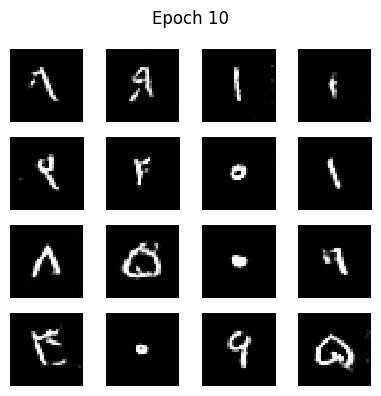


Epoch 11/15
  Batch 50: D=0.6779, G=0.8277
  Batch 100: D=0.6806, G=0.8326
  Batch 150: D=0.6760, G=0.8272
  Batch 200: D=0.6762, G=0.8282
  Batch 250: D=0.6783, G=0.8238
  Batch 300: D=0.6755, G=0.8264
  Batch 350: D=0.6768, G=0.8255
  Batch 400: D=0.6796, G=0.8201
  Batch 450: D=0.6781, G=0.8235
  Batch 500: D=0.6789, G=0.8206
  Batch 550: D=0.6743, G=0.8189
  Batch 600: D=0.6818, G=0.8229
  Batch 650: D=0.6774, G=0.8195
  Batch 700: D=0.6779, G=0.8179
  Batch 750: D=0.6778, G=0.8154
  Batch 800: D=0.6797, G=0.8119
  Batch 850: D=0.6791, G=0.8256
  Batch 900: D=0.6771, G=0.8267
  Batch 950: D=0.6791, G=0.8304
  Batch 1000: D=0.6796, G=0.8085
  Batch 1050: D=0.6793, G=0.8165
  Batch 1100: D=0.6790, G=0.8152
  Batch 1150: D=0.6787, G=0.8185
  Batch 1200: D=0.6750, G=0.8242
  Batch 1250: D=0.6758, G=0.8310
  Batch 1300: D=0.6756, G=0.8368
  Batch 1350: D=0.6763, G=0.8121
  Batch 1400: D=0.6816, G=0.8181
  Batch 1450: D=0.6776, G=0.8231
  Batch 1500: D=0.6812, G=0.8046
  Batch 1550: D=0

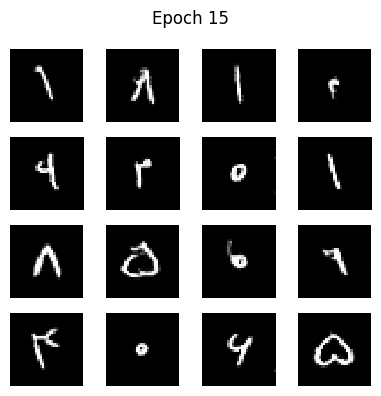

In [13]:
# ============================================================
# 13) Train the DCGAN
# ============================================================

history = train_gan(train_dataset, CONFIG)

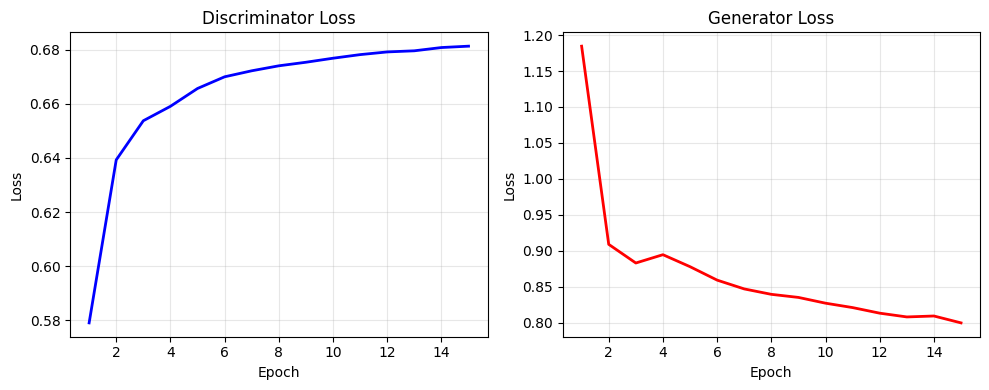

In [14]:
# ============================================================
# 14) Plot loss curves
# ============================================================

epochs_range = range(1, len(history['d_loss']) + 1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['d_loss'], 'b-', linewidth=2)
plt.title('Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['g_loss'], 'r-', linewidth=2)
plt.title('Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close('all')

In [15]:
# ============================================================
# 15) Save and download the Generator
# ============================================================

output_dir = '/content/saved_models'
os.makedirs(output_dir, exist_ok=True)

generator_path = os.path.join(output_dir, 'generator.keras')
generator.save(generator_path)

print(f"Generator model saved to: {generator_path}")

try:
    from google.colab import files
    files.download(generator_path)
except Exception as e:
    print("Download is available when running inside Google Colab.")
    print(e)

Generator model saved to: /content/saved_models/generator.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>